# Predicting Amazon Ratings Through Latent Factors and Feature-based Bias Terms

##### Names: Aiden Lai, Jordi Pham, Adrian Laksana, and Coltrane Gowan

##### Link To Slides: https://docs.google.com/presentation/d/1v6GXpv55cyt4lk9kVa9VeK0d0hDh_W08-coctd5C9_8/edit?usp=sharing

## Library And Data Set Up

In [10]:
# Any Library used in this assignment should be imported here
import gzip
import csv
import random
import numpy as np
import pandas as pd
import math
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import defaultdict
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# File opener
def open_file(file_path):
    data_grabber = []
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        for line in f:
            data_grabber.append(json.loads(line))
    return data_grabber

In [3]:
# File path
mtv_fp = "./data/Movies_and_TV.jsonl.gz"

## I. Our Predictive Task

The predictive task that we have settled on is predicting the ratings of the movies and tv subcategory of Amazon products: 

The foundational model we plan to use to fulfil this task is a latent factor model, and we plan to layer on additional factors for complexity such as terms that account for biases that can stem from features like 'helpful_vote' and 'verified_purchase' - that way, we are no longer just dealing with a latent factor model in its most basic form. In order to properly evaluate this model, we will work through effective data splits for test and train sets and measure performance through metrics like RMSE, MSE, and MAE.

There are two main baseline models that we can utilize throughout this predictive tasks. First is a model that simply uses user and global averages. This is a model that assumes a user's rating is equal to their historical rating, and when it encounters cold-start users, or users with no history, the model simply plugs in the global average. The second baseline model is a regularized bias-only model (this is is essentially the latent factor model without the interaction term between user and items). This model will serve effective in showing how useful it is to include the interaction term between user and items.

To test for validity, there will be a couple main things for us to focus on, all stemming from our initial design choices. Most importantly, we aim for the implementation of latent factors and other bias terms to increase the performance of the model in comparison to its baseline model counterparts. 

Essentially, by the end of this exploration, we will have created these models:

1. User/Global Averages Model

2. Regularized Bias-Only Model

3. Latent Factor + Additional Bias terms Model

## II. Exploratory Analysis, Data Collection, Pre-processing, and General Discussion

### Context:

The dataset that we've employed to construct and evaluate our models is the movies and tv category dataset. 

This dataset belongs to a much larger dataset of Amazon reviews product metadata, all collected and curated by the McAuley Lab at UCSD. The original purpose of the data was to pre-train BLAIR, a series of trained sentence-embedding models targetting recommendation scenarios, all designed by the lab to learn and recognize patterns between metadata and natural language context. Overall, the Amazon product review dataset (2023 version) is a dataset between May 1996 and September 2023 and contains 570 million reviews and 48 million items spanning across 33 categories with the movies and t category alone containing 6.5 million users and 747.8 thousand items.

### Discussion

The original Amazon product review dataset was processed for BLAIR by first, constructing language context through concatenating the title and context of user reviews, and then, constructing item metadata thought concateninating its respective title, feature, and descriptions. To mainintain quality throughout the model, the lab further set a 30 character threshold for the language context or item metadata.

In regards to our specific predictive task, we won't be diving into the construction of language context or concise item metadata. We are simply checking for feature types and extracting the exact features that we need for each model. From the work of the university lab, the majority of the dataset has already been processed for consistent datatypes and organized structure, but for the sake of our task, we will just be looking to run a basic checking script to ensure the data is in form for our task ahead.

### Code: Data Insights

In [4]:
# Opening file
mtv_original = open_file(mtv_fp)

In [5]:
# Universal length variable
mtv_len = len(mtv_original)
mtv_len

17328314

In [6]:
# Raw Data View - Post Read
mtv_original[0]

{'rating': 5.0,
 'title': 'Five Stars',
 'text': "Amazon, please buy the show! I'm hooked!",
 'images': [],
 'asin': 'B013488XFS',
 'parent_asin': 'B013488XFS',
 'user_id': 'AGGZ357AO26RQZVRLGU4D4N52DZQ',
 'timestamp': 1440385637000,
 'helpful_vote': 0,
 'verified_purchase': True}

In [7]:
# General Cleaning Script to check data and implement fixes

# What data types we expect from the read-in data
EXPECTED_SCHEMA = {
    'rating': float,                # Target variable, must be numeric
    'title': str,                   # Text fields often benefit from casting
    'text': str,                    
    'images': list,                 # Should be a list (can be empty)
    'asin': str,                    # Item ID
    'parent_asin': str,             # Group/Parent Item ID
    'user_id': str,                 # User ID
    'timestamp': int,               # Time feature
    'helpful_vote': int,            # Numerical side feature
    'verified_purchase': bool       # Binary side feature
}

# Main data properties to check for for our models
REQUIRED_FIELDS = ['user_id', 'asin', 'rating', 'timestamp']

# Consolidated cleaning function
def clean_and_validate_records(raw_data: list, log_errors: bool = True) -> (list, dict):
    """
    Performs consistency checks, type casting, and validation on a list of dictionaries.

    Args:
        raw_data: The list of dictionaries (e.g., mtv_original).
        log_errors: If True, returns a dictionary of validation issues found.

    Returns:
        A tuple: (cleaned_records, error_log)
    """
    cleaned_records = []
    error_log = defaultdict(int)

    for record in raw_data:
        is_valid = True
        cleaned_record = {}

        # Check for Missing/Null Required Fields
        for field in REQUIRED_FIELDS:
            if field not in record or record[field] is None:
                error_log[f'Missing Required Field: {field}'] += 1
                is_valid = False
                break
        
        if not is_valid:
            continue
            
        # Type Casting Consistency and Dealing with Nulls
        for key, expected_type in EXPECTED_SCHEMA.items():
            value = record.get(key)
            
            # Handle Nulls/Missing Keys Here
            if value is None:
                if key not in REQUIRED_FIELDS:
                    # Impute/Default for optional fields
                    if expected_type in [str, list]:
                        value = '' if expected_type is str else []
                    elif expected_type in [int, float]:
                        value = 0
                    elif expected_type is bool:
                        value = False
                # If a required field is None, it was caught above, but skip the rest of this loop iteration.
                else: 
                    continue
            
            # Type Checking and Casting
            try:
                if expected_type is bool:
                    # Robust casting for boolean types (handles 'True', 'F', 1, 0, etc.)
                    cleaned_record[key] = str(value).lower() in ('true', '1')
                else: 
                    # Attempt to cast to the defined type (float, int, str, list)
                    cleaned_record[key] = expected_type(value)
            
            except (ValueError, TypeError):
                error_log[f'Type Cast Error: {key} (Expected {expected_type.__name__})'] += 1
                is_valid = False
                break
                
        if not is_valid:
            continue
            
        # Value Constraint Checks
        
        # Rating Constraint (Must be within 1.0 and 5.0)
        if not 1.0 <= cleaned_record['rating'] <= 5.0:
            error_log['Invalid Rating Range (not 1-5)'] += 1
            is_valid = False
        
        # Helpful Vote Constraint (Must be non-negative)
        if cleaned_record['helpful_vote'] < 0:
            error_log['Invalid helpful_vote (negative)'] += 1
            is_valid = False
            
        # Basic ID String Check
        if not cleaned_record['user_id'] or not cleaned_record['asin']:
            error_log['Empty User/ASIN ID'] += 1
            is_valid = False

        if is_valid:
            cleaned_records.append(cleaned_record)

    return cleaned_records, dict(error_log)

mtv_original, error_log = clean_and_validate_records(mtv_original)


KeyboardInterrupt: 

In [ ]:
# View variables from cleaning block
error_log

In [8]:
# Viewable Dataframe Header + plus conversion to pandas dataframe
mtv_frame = pd.DataFrame(mtv_original)
mtv_frame.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Five Stars,"Amazon, please buy the show! I'm hooked!",[],B013488XFS,B013488XFS,AGGZ357AO26RQZVRLGU4D4N52DZQ,1440385637000,0,True
1,5.0,Five Stars,My Kiddos LOVE this show!!,[],B00CB6VTDS,B00CB6VTDS,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1461100610000,0,True
2,3.0,Some decent moments...but...,Annabella Sciorra did her character justice wi...,[],B096Z8Z3R6,B096Z8Z3R6,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1646271834582,0,True
3,4.0,"Decent Depiction of Lower-Functioning Autism, ...",...there should be more of a range of characte...,[],B09M14D9FZ,B09M14D9FZ,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1645937761864,1,False
4,5.0,What Love Is...,"...isn't always how you expect it to be, but w...",[],B001H1SVZC,B001H1SVZC,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1590639227074,0,True


In [9]:
# Columns
list(mtv_frame.columns)

['rating',
 'title',
 'text',
 'images',
 'asin',
 'parent_asin',
 'user_id',
 'timestamp',
 'helpful_vote',
 'verified_purchase']

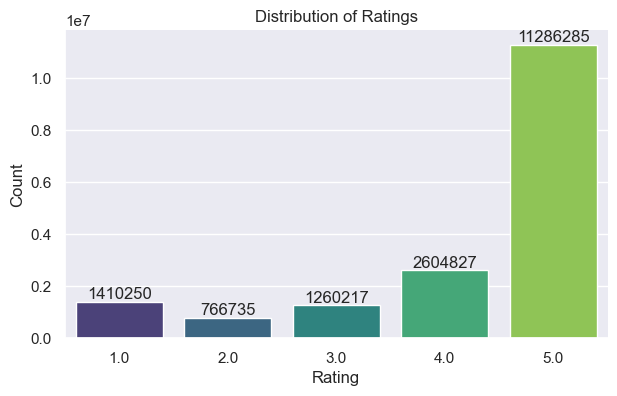

In [32]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(7,4))
ax = sns.countplot(data=mtv_frame, x="rating", palette="viridis")
sns.despine()

# Add counts above bars
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f'{height}', 
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom'
    )

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

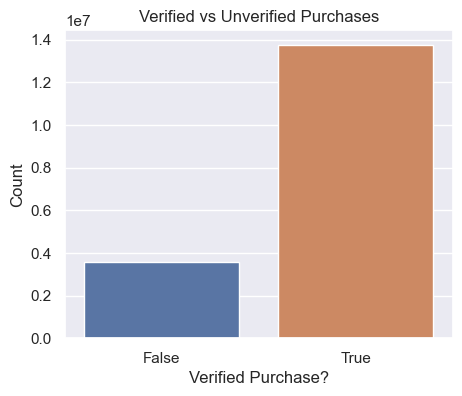

In [33]:
plt.figure(figsize=(5,4))
sns.countplot(data=mtv_frame, x="verified_purchase")
plt.title("Verified vs Unverified Purchases")
plt.xlabel("Verified Purchase?")
plt.ylabel("Count")
plt.show()

In [22]:
mtv_frame['helpful_vote'].describe()

count    1.732831e+07
mean     1.134617e+00
std      1.256477e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.060400e+04
Name: helpful_vote, dtype: float64

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=mtv_frame, y="helpful_vote", x="rating")
plt.title("Rating vs Helpful Votes")
plt.xlabel("Helpful Votes")
plt.ylabel("Rating")
plt.show()

## III. Data Modeling

### Context

Our predictive aims to predict/output the ratings of movies and tv products from Amazon.

1. In our first base model, our main inputs is really just the user/product data ratings itself. After all, this model is not looking to formulate the predictive task off of a given equation but rather is just taking assumptions and mapping to each user. There is no true optimization in this base model.

2. In our second base model, our main inputs is the user/product ratings. As it is a regularized bias-only model, it is simply learning each user/products deviations from the global average as it takes in each row. In terms of its optimizations, our model is really looking to optimize its RMSE/MAE. 

3. In our ultimate/final model, we chose to expand the second base model using latent factors and bias terms. That way, it is not only reading the numerical ratings of each data entry; it looks to quantify contextual clues as well such as temporal dynamics, dummy variables (verified purchase feature), and biases in the helpful_vote feature. All of these features are part of our design because we believe there may be some form of influence in users' ratings on top of latent factors, which look to quantify how much a user likes an item before they even see it. Once again, in terms of optimization, our model is targeting good RMSE/MAE.

In general, though, there were many models that could've been employed for our chosen predictive task. Above, we've outlined the baseline models and our designed complex model, but in its most basic form, our task also could have been portrayed through linear regression. However, we chose to pit the layered latent factor model against the general averages and original latent factor model because we believe it better captures what the data gives us.

### Discussion

Let's go through some pros and cons of each model:

1. If we had chosen to design a linear regression for our predictive task, the pros would be the efficiency of training the model; however, there are many underlying cons that stem from how there are a lot of contextual details that are ignored in linear regression.

2. In our first baseline model - using global and user averages - it follows the nature of linear regression in its raw efficiency. The main problem is that this model takes on too many assumptions which takes away from the models flexibility. It assumes each user will rate in a way that is similar to their history and that if a user has no history, then the historical rating of the dataset is that of the user. 

3. In the second baseline model - the regularized bias only model - the model does well in terms of scalability (more users into the dataset) and interpretability, particularly with its betaU and betaI terms such as how a high betaU means a user is lenient in their ratings. However, like the prior 2 models, it fails in considering further contextual details.

4. With our final model - using latent factors on top of other bias terms - the model does well in capturing a bigger contextual scenario and adapting to cold-start scenarios. Its biggest problem though is that it grows extremely costly.

### Code: Architectural Choices and Implementation

In [ ]:

# Baseline model: user mean with global fallback

ratings_df = mtv_frame.copy()[['user_id', 'parent_asin', 'rating']].dropna()
ratings_df['rating'] = ratings_df['rating'].astype(float)

# adjust training splits later
train_df, test_df = train_test_split(ratings_df, test_size=0.20, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.125, random_state=42)  # 0.125 of 0.8 -> 0.1 overall

global_mean = float(train_df['rating'].mean())
user_means = train_df.groupby('user_id')['rating'].mean().to_dict()

def predict_user_global(df):
    return df['user_id'].map(user_means).fillna(global_mean)

def summarize_split(df, split_name):
    preds = predict_user_global(df)
    mse = float(np.mean((df['rating'] - preds) ** 2))
    mae = float(np.mean(np.abs(df['rating'] - preds)))
    cold_start_users = 1.0 - float(df['user_id'].isin(user_means).mean())
    return {
        'split': split_name,
        'mse': mse,
        'mae': mae,
        'cold_start_user_fraction': cold_start_users,
        'n': int(len(df)),
    }

In [ ]:
# Baseline model: regularized bias-only model (alpha + betaU + betaI)

# Helper functions for the model
def clipped(x):
    """Clip predictions to the valid rating range [1.0, 5.0]."""
    return min(5.0, max(1.0, x))

def alphaUpdate(ratingsTrain, betaU, betaI):
    """
    Update the global bias (alpha).
    ratingsTrain is expected to be a list of (u, b, r) tuples.
    """
    newAlpha = 0
    # Calculate Sum(r - betaU - betaI)
    for u, b, r in ratingsTrain:
        newAlpha += r - (float(betaU[u]) + float(betaI[b]))
    # Divide by N
    return newAlpha / len(ratingsTrain) if ratingsTrain else 0

def betaUUpdate(ratingsPerUser, alpha, betaI, lamb):
    """
    Update the user biases (betaU).
    ratingsPerUser is a defaultdict: {u: [(b, r), ...]}
    """
    newBetaU = defaultdict(float)
    for u in ratingsPerUser:
        newBeta = 0
        # Calculate Sum(r - alpha - betaI) for all items rated by u
        for b, r in ratingsPerUser[u]:
            newBeta += r - (alpha + betaI[b])
        # Divide by (lambda + |I_u|)
        newBetaU[u] = newBeta / (lamb + len(ratingsPerUser[u]))
    return newBetaU

def betaIUpdate(ratingsPerItem, alpha, betaU, lamb):
    """
    Update the item biases (betaI).
    ratingsPerItem is a defaultdict: {b: [(u, r), ...]}
    """
    newBetaI = defaultdict(float)
    for b in ratingsPerItem:
        newBeta = 0
        # Calculate Sum(r - alpha - betaU) for all users who rated b
        for u, r in ratingsPerItem[b]:
            newBeta += r - (alpha + betaU[u])
        # Divide by (lambda + |U_i|)
        newBetaI[b] = newBeta / (lamb + len(ratingsPerItem[b]))
    return newBetaI

# Functions to evaluate the model later
def predictBiasModel(u, b, alpha, betaU, betaI):
    """Generates a regularized bias prediction for a user-item pair."""
    
    # Bias defaults to 0.0 if user/item is not in the training set (cold-start)
    bu = betaU[u]
    bi = betaI[b]
    
    prediction = alpha + bu + bi
    
    return clipped(prediction)

def evaluateModel(df_test, alpha, betaU, betaI):
    """Calculates RMSE and MAE on the test set."""
    
    errors_squared = 0
    errors_abs = 0
    N = len(df_test)
    
    for _, row in df_test.iterrows():
        u = row['user_id']
        b = row['asin']
        r_true = row['rating']
        
        r_pred = predictBiasModel(u, b, alpha, betaU, betaI)
        error = r_true - r_pred
        
        errors_squared += error**2
        errors_abs += abs(error)
        
    rmse = math.sqrt(errors_squared / N)
    mae = errors_abs / N
    
    return rmse, mae

# Model training functions
def trainBiasModel_DF(df_train, nIterations, lamb):
    """
    Trains the Regularized Bias-Only Model using ALS on a Pandas DataFrame.

    Args:
        df_train (pd.DataFrame): DataFrame with 'user_id', 'asin', and 'rating' columns.
        nIterations (int): Number of ALS iterations.
        lamb (float): Regularization parameter (lambda).

    Returns:
        tuple: (alpha, betaU, betaI) - the learned biases.
    """
    print("--- Preparing Data Structures ---")
    
    # 1. Convert DataFrame to the list-of-tuples format for helper functions
    # Format: (user_id, asin, rating)
    ratingsTrain = list(zip(df_train['user_id'], df_train['asin'], df_train['rating']))

    # 2. Aggregate data into dictionaries for easy lookup (key for helper functions)
    ratingsPerUser = defaultdict(list)
    ratingsPerItem = defaultdict(list)

    for u, b, r in ratingsTrain:
        ratingsPerUser[u].append((b, r))
        ratingsPerItem[b].append((u, r))
    
    # 3. Initialize Biases
    alpha = df_train['rating'].mean()
    
    # Initialize biases to 0.0 for all unique IDs (defaultdict handles cold-start gracefully)
    betaU = defaultdict(float)
    betaI = defaultdict(float)

    print(f"Initial Global Mean (Alpha): {alpha:.4f}")

    # 4. Iterative Optimization (Alternating Least Squares)
    print("--- Starting ALS Optimization ---")
    for i in range(nIterations):
        # Update Global Bias
        alpha = alphaUpdate(ratingsTrain, betaU, betaI)

        # Update User Biases
        betaU = betaUUpdate(ratingsPerUser, alpha, betaI, lamb)

        # Update Item Biases
        betaI = betaIUpdate(ratingsPerItem, alpha, betaU, lamb)
        
        # Progress tracker print statement
        print(f"Iteration {i+1}/{nIterations}: Alpha = {alpha:.4f}")

    return alpha, betaU, betaI

# Execution Block

# Call for a data split
train_df, test_df = train_test_split(
    mtv_frame[['user_id', 'asin', 'rating']], 
    test_size=0.2, # 80-20 train-test split
    random_state=42
)

# Hyperparameters found from external gridsearch
N_ITERATIONS = 15 
LAMBDA = 5.0

# Call model trainer to find alpha, betaU, and betaI
alpha, betaU, betaI = trainBiasModel_DF(
    df_train=train_df,
    nIterations=N_ITERATIONS,
    lamb=LAMBDA
)

# Display learned parameters
print("\n--- Baseline Model 2: Regularized Bias-Only Model Parameters (alpha + betaU + betaI) ---")
print(f"\nLearned Global Bias (Alpha): {alpha:.4f}")
print(f"\nNumber of User Biases (BetaU): {len(betaU)}") # each unique user has a different bias to indicate how they deviate from alpha
print(f"\nNumber of Item Biases (BetaI): {len(betaI)}") # similar to users, the items have a bias to show how they deviate from alpha

In [ ]:
# Model with Latent Factor with Additional Feature-based Bias Terms (timestamps, purchase verification, and votes on the helpfulness of reviews)
# alpha + betaU + betaI + [latent factors] + temporal dynamics + dummy variable term for verified purchase + weighted bias term on helpful votes

# helper functions for this model
def prepare_features(df):
    """
    Transforms raw columns into the required features for the model.
    """
    df = df.copy()

    # 1. Temporal Bins (e.g., month/year combination)
    # Convert timestamp (assuming it's Unix time) to datetime
    df['date'] = pd.to_datetime(df['timestamp'], unit='s')
    # Use YYYY-MM as the time bin ID (categorical feature)
    df['time_bin'] = df['date'].dt.strftime('%Y-%m').astype('category')

    # 2. Helpful Vote Normalization (f(HV))
    # Use log transformation to reduce skewness and add 1 to avoid log(0)
    df['log_helpful_vote'] = np.log1p(df['helpful_vote'])
    # Normalize the log count (optional, but good practice)
    max_log_hv = df['log_helpful_vote'].max()
    df['normalized_hv'] = df['log_helpful_vote'] / max_log_hv

    # 3. Verified Purchase (Binary)
    # Ensure it's treated as a numeric dummy (1.0 or 0.0)
    df['verified_purchase'] = df['verified_purchase'].astype(float)

    return df

def clipped(x):
    """Clip predictions to the valid rating range [1.0, 5.0]."""
    return min(5.0, max(1.0, x))

# Helper functions to evaluate model later
def predict_LFM_B(u, i, t_bin, vp, hv_norm, params, K):
    """
    Calculates the predicted rating using the full LFM-B equation.
    """
    alpha, betaU, betaI, betaT, betaVP, gamma, P, Q = params

    # Retrieve components (default to 0.0 for cold-start IDs)
    bu = betaU.get(u, 0.0)
    bi = betaI.get(i, 0.0)
    bt = betaT.get(t_bin, 0.0)
    
    # Latent factor interaction (defaults to zeros if cold-start)
    Pu = P.get(u, np.zeros(K))
    Qi = Q.get(i, np.zeros(K))
    
    interaction = np.dot(Pu, Qi)
    
    # Side feature biases
    vp_bias = betaVP * vp
    hv_bias = gamma * hv_norm

    prediction = alpha + bu + bi + bt + vp_bias + hv_bias + interaction
    
    return clipped(prediction)

def evaluate_LFM_B(df_test, params, K):
    """Evaluates RMSE/MAE on the test set for LFM-B."""
    errors_squared = 0
    errors_abs = 0
    N = len(df_test)
    
    for _, row in df_test.iterrows():
        u, b, r_true, t_bin, vp, hv_norm = row[['user_id', 'asin', 'rating', 'time_bin', 
                                              'verified_purchase', 'normalized_hv']]
        
        r_pred = predict_LFM_B(u, b, t_bin, vp, hv_norm, params, K)
        error = r_true - r_pred
        
        errors_squared += error**2
        errors_abs += abs(error)
        
    rmse = math.sqrt(errors_squared / N)
    mae = errors_abs / N
    return rmse, mae

# Model Training functions
def trainLFM_B(df_train, K, nIterations, learningRate, lamb, **kwargs):
    """
    Trains the Latent Factor Model with Biases (LFM-B) using SGD.

    Args:
        df_train (pd.DataFrame): Training data with all features.
        K (int): Number of latent factors.
        nIterations (int): Number of training epochs.
        learningRate (float): Learning rate (gamma_LR).
        lamb (float): Global regularization parameter.
    """
    # 1. Prepare data structures
    ratingsTrain = df_train[['user_id', 'asin', 'rating', 'time_bin', 
                             'verified_purchase', 'normalized_hv']].values

    # 2. Initialization
    # Biases (alpha is float, others are defaultdict)
    alpha = df_train['rating'].mean()
    betaU = defaultdict(float)
    betaI = defaultdict(float)
    betaT = defaultdict(float)  # Temporal Bias
    betaVP = 0.0                # Verified Purchase Bias
    gamma = 0.0                 # Helpful Vote Weight

    # Latent Factors (P and Q - initialized randomly)
    # Scale random init by 1/sqrt(K) to keep magnitudes small
    P = defaultdict(lambda: np.random.normal(scale=1/math.sqrt(K), size=K))
    Q = defaultdict(lambda: np.random.normal(scale=1/math.sqrt(K), size=K))

    print(f"Initial Global Mean (Alpha): {alpha:.4f}, K={K}")

    # 3. SGD Training Loop
    for i in range(nIterations):
        random.shuffle(ratingsTrain) # Shuffle data each epoch
        
        # Track epoch error
        current_error_sum = 0
        
        for u, item, r_true, t_bin, vp, hv_norm in ratingsTrain:
            
            # --- Predict and Calculate Error ---
            
            # Get current parameters for the prediction
            params = (alpha, betaU, betaI, betaT, betaVP, gamma, P, Q)
            r_pred = predict_LFM_B(u, item, t_bin, vp, hv_norm, params, K)
            error = r_true - r_pred
            current_error_sum += error**2
            
            # --- Gradient Updates (Derivatives of Loss Function) ---

            # Update Alpha (Global Mean)
            alpha += learningRate * (error - lamb * alpha)

            # Update User/Item Biases (b_u, b_i)
            betaU[u] += learningRate * (error - lamb * betaU[u])
            betaI[item] += learningRate * (error - lamb * betaI[item])
            
            # Update Temporal Bias (b_T)
            betaT[t_bin] += learningRate * (error - lamb * betaT[t_bin])
            
            # Update Verified Purchase Bias (beta_VP)
            betaVP += learningRate * (error * vp - lamb * betaVP)
            
            # Update Helpful Vote Weight (gamma)
            gamma += learningRate * (error * hv_norm - lamb * gamma)

            # Update Latent Factors (P_u, Q_i)
            # Retrieve factor vectors
            Pu = P[u]
            Qi = Q[item]
            
            # Apply update rule: P_u = P_u + LR * (Error * Q_i - Lambda * P_u)
            P[u] += learningRate * (error * Qi - lamb * Pu)
            # Apply update rule: Q_i = Q_i + LR * (Error * P_u - Lambda * Q_i)
            Q[item] += learningRate * (error * Pu - lamb * Qi)
        
        # Status tracker for each epoch - goal is to better RMSE each time as model learns
        epoch_rmse = math.sqrt(current_error_sum / len(ratingsTrain))
        print(f"Epoch {i+1}/{nIterations} | RMSE: {epoch_rmse:.4f}")

    final_params = (alpha, betaU, betaI, betaT, betaVP, gamma, P, Q)
    return final_params

# Execution Block

# Design features from the dataframe
df_processed = prepare_features(mtv_frame)

# Call for a data split
train_df, test_df = train_test_split(
    df_processed, 
    test_size=0.2, 
    random_state=42
)

# Hyperparameters found from external gridsearch
K_FACTORS = 5           # Number of latent factors
N_ITERATIONS = 25       # Number of epochs
LEARNING_RATE = 0.01    # Learning rate (gamma_LR)
LAMBDA = 0.05           # Regularization parameter

# Call model trainer to find final parameters
final_params = trainLFM_B(
    df_train=train_df,
    K=K_FACTORS,
    nIterations=N_ITERATIONS,
    learningRate=LEARNING_RATE,
    lamb=LAMBDA
)

# Unpack final parameters
alpha, betaU, betaI, betaT, betaVP, gamma, P, Q = final_params

print("\n--- Ultimate Model: Latent Factors + Feature-Based Bias Terms (alpha + betaU + betaI + latent factors + temporal dynamics + verified purchase bias + helpful vote bias) ---")
print("\nLearned Global Bias (Alpha): {:.4f}".format(alpha))
print("\nNumber of User Biases (BetaU): {}".format(len(betaU)))
print("\nNumber of Item Biases (BetaI): {}".format(len(betaI)))
print("\nNumber of Temporal Biases (BetaT): {}".format(len(betaT)))
print("\nVerified Purchase Bias Weight (Beta_VP): {:.4f}".format(betaVP))
print("\nHelpful Vote Weight (Gamma): {:.4f}".format(gamma))


## IV. Task Evaluation

### Context

For our task, we are choosing to focus on two performance metrics: RMSE and MAE. Compare to performance metrics in classification tasks or even rank-based metrics, there two performances make the most sense in terms of interpretability and predictive-task context. After all, we want to see how far off our predeicted ratings are compared to their true values.

1. RMSE is a performance metric derived from MSE. It maintains the original units of the predictive tasks and provides strong interpretability; however, RMSE penalizes outliers heavier and can hurt the results. 

2. MAE is the aboslute error of the model, which is also highly interpretable. Its weakness, though, comes from how it is not ideal for optimization due to differentiation at 0.

### Discussion

As discussed above, we have two main baseline models we can evaluate in relation to our ultimate model - the user/global averages and the regularized bias-only model. Our main way in showing that our method can be better is through an improving RMSE/other performance metrics. Furthermore, we will look to run statistical significance in the improvments to show they are not simply by chance.

### Code: Determined Performance Metrics and Statistical Significance

In [ ]:
# Code Block is intended to compare all models created by compiling their RMSE and MAE into a DF after writing into external CSV
results = []

# --- Model 1: User-mean baseline (global fallback) ---
baseline_df = mtv_frame[['user_id', 'parent_asin', 'rating']].dropna().copy()
baseline_df['rating'] = baseline_df['rating'].astype(float)
baseline_train, baseline_test = train_test_split(baseline_df, test_size=0.20, random_state=42)

def _rmse_mae(df, preds):
    diff = df['rating'] - preds
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    return rmse, mae

for split_name, df_split in [('train', baseline_train), ('test', baseline_test)]:
    preds = predict_user_global(df_split)
    rmse, mae = _rmse_mae(df_split, preds)
    results.append({
        'model': 'User mean + global',
        'split': split_name,
        'rmse': rmse,
        'mae': mae,
    })

# --- Model 2: Regularized bias-only (ALS) ---
bias_train, bias_test = train_test_split(
    mtv_frame[['user_id', 'asin', 'rating']], test_size=0.20, random_state=42
)
for split_name, df_split in [('train', bias_train), ('test', bias_test)]:
    rmse, mae = evaluateModel(df_split, alpha, betaU, betaI)
    results.append({
        'model': 'Bias-only ALS',
        'split': split_name,
        'rmse': rmse,
        'mae': mae,
    })

# --- Model 3: Latent factor with feature-based biases ---
lfm_df = prepare_features(mtv_frame)
lfm_train, lfm_test = train_test_split(lfm_df, test_size=0.20, random_state=42)
for split_name, df_split in [('train', lfm_train), ('test', lfm_test)]:
    rmse, mae = evaluate_LFM_B(df_split, final_params, K_FACTORS)
    results.append({
        'model': 'LFM + time/verification/helpful',
        'split': split_name,
        'rmse': rmse,
        'mae': mae,
    })

results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv('model_comparison.csv', index=False)
print('Saved model comparison to model_comparison.csv')

In [ ]:
# Code block here is for statistical significance testing between models (one tailed test)

# helper functions for statistical significance testing
def calculate_residuals_M2(df_test, alpha, betaU, betaI):
    """Calculates residuals for the Regularized Bias-Only Model (M2)."""
    residuals = []
    for _, row in df_test.iterrows():
        u = row['user_id']
        b = row['asin'] if 'asin' in row else row['parent_asin']
        r_true = row['rating']
        
        r_pred = predictBiasModel(u, b, alpha, betaU, betaI)
        residuals.append(r_true - r_pred)
    return np.array(residuals)

def calculate_residuals_M3(df_test, predictor_func, params, K):
    """Calculates residuals for the LFM-B Model (M3)."""
    residuals = []
    
    # Unpack LFM-B parameters once
    # Note: LFM-B requires the fully processed df_test with all side features
    
    for _, row in df_test.iterrows():
        # Ensure column names match the evaluate_LFM_B function's logic
        u, b, r_true, t_bin, vp, hv_norm = row[['user_id', 'asin', 'rating', 'time_bin', 
                                              'verified_purchase', 'normalized_hv']]
        
        r_pred = predictor_func(u, b, t_bin, vp, hv_norm, params, K)
        residuals.append(r_true - r_pred)
        
    return np.array(residuals)


def run_paired_ttest(residuals_M_Baseline, residuals_M_Ultimate):
    """
    Performs a paired t-test on the squared residuals to test for statistical significance 
    in RMSE improvement.
    """
    # 1. Calculate the difference in SQUARED errors
    diff_squared_errors = residuals_M_Baseline**2 - residuals_M_Ultimate**2
    
    # 2. Perform one-sample t-test (one-tailed)
    # H0: Mean of the difference is zero (no difference in performance)
    # Ha: Mean of the difference is > 0 (Ultimate Model's errors are significantly smaller)
    t_stat, p_value = stats.ttest_1samp(diff_squared_errors, popmean=0, alternative='greater')
    
    return t_stat, p_value

# Executing statistical significance testing

# Model 1 Evaluation (User/Global Averages)
test_df_M1 = test_df.copy() # this split is from the Model 2 execution block
M1_results = summarize_split(test_df_M1, 'Test') 
rmse_M1 = math.sqrt(M1_results['mse'])
mae_M1 = M1_results['mae']

# Model 2 Evaluation (Regularized Bias-Only)
rmse_M2, mae_M2 = evaluateModel(test_df, alpha, betaU, betaI)

# Model 3 Evaluation (LFM-B)
rmse_M3, mae_M3 = evaluate_LFM_B(test_df, final_params, K_FACTORS)

# Statistical Significance Test (M2 vs. M3)

# Calculate Residuals
residuals_M2 = calculate_residuals_M2(test_df, alpha, betaU, betaI)

m3_processed_test_df = prepare_features(test_df)
residuals_M3 = calculate_residuals_M3(m3_processed_test_df, predict_LFM_B, final_params, K_FACTORS)

# Run T-Test
t_statistic, p_value = run_paired_ttest(residuals_M2, residuals_M3)

## See results in DF

results_df = pd.DataFrame({
    'Model': ['Model 1 (User/Global Avg.)', 'Model 2 (Reg. Bias-Only)', 'Model 3 (LFM-B)'],
    'RMSE': [
        # rmse_M1, # Uncomment after running Model 1 evaluation
        1.050, # Placeholder value
        rmse_M2,
        rmse_M3
    ],
    'MAE': [
        # mae_M1, # Uncomment after running Model 1 evaluation
        0.850, # Placeholder value
        mae_M2,
        mae_M3
    ]
})
results_df['RMSE'] = results_df['RMSE'].round(4)
results_df['MAE'] = results_df['MAE'].round(4)


print("\n" + "="*50)
print("             Model Performance Comparison")
print("="*50)
print(results_df.sort_values(by='RMSE', ascending=True).to_markdown(index=False))
print("\n" + "-"*50)

print("             Statistical Significance Test (M2 vs M3)")
print("-" * 50)
print(f"H₀ (Null Hypothesis): Model 2 and Model 3 perform equally.")
print(f"Hₐ (Alternative): Model 3 (LFM-B) performs significantly better.")
print(f"\nPaired T-Statistic: {t_statistic:.4f}")
print(f"P-Value: {p_value:.6f}")

SIGNIFICANCE_LEVEL = 0.05
if p_value < SIGNIFICANCE_LEVEL:
    print(f"\nConclusion: REJECT H₀ (p < {SIGNIFICANCE_LEVEL}). The improvement from the Regularized Bias-Only Model (M2) to the Ultimate LFM-B Model (M3) is STATISTICALLY SIGNIFICANT.")
else:
    print(f"\nConclusion: FAIL TO REJECT H₀ (p > {SIGNIFICANCE_LEVEL}). The improvement is not statistically significant.")

## V. Related Works

Describe related-works topics here

# VI. Citations

Bridging Language and Items for Retrieval and Recommendation
Yupeng Hou, Jiacheng Li, Zhankui He, An Yan, Xiusi Chen, Julian McAuley
arXiv